### load Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### load the dataset

In [2]:
df = pd.read_csv('Mall_Customers.csv')

### see the first 5 values

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Data Preprocessing

### drop the column CustomerID

In [4]:
df.drop(columns=['CustomerID'], inplace=True)

In [5]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.0,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.0,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.0,99.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [8]:
df.isnull().sum()

Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

## Duplicates

In [9]:
df[df.duplicated()]

,Gender,Age,Annual Income (k$),Spending Score (1-100)


In [10]:
df.shape

(200, 4)

In [11]:
## visualization of numerical colilms

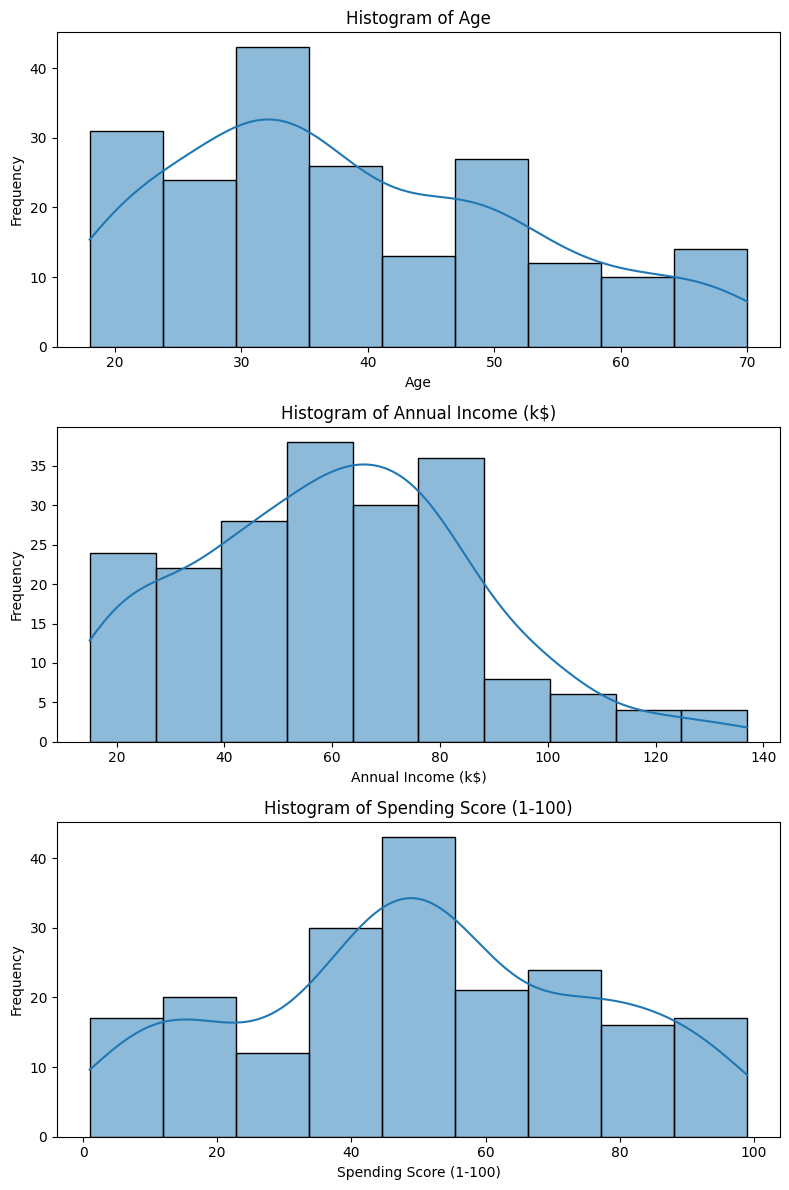

In [12]:
num_columns = [col for col in df.columns if df[col].dtype != object]
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(8, len(num_columns) * 4))
if len(num_columns) == 1:
    axes = [axes]

for i, col in enumerate(num_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])  
    axes[i].set_title(f'Histogram of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout() 
plt.show()

## Outliers

In [13]:
num_columns = [col for col in df.columns if df[col].dtype != object]

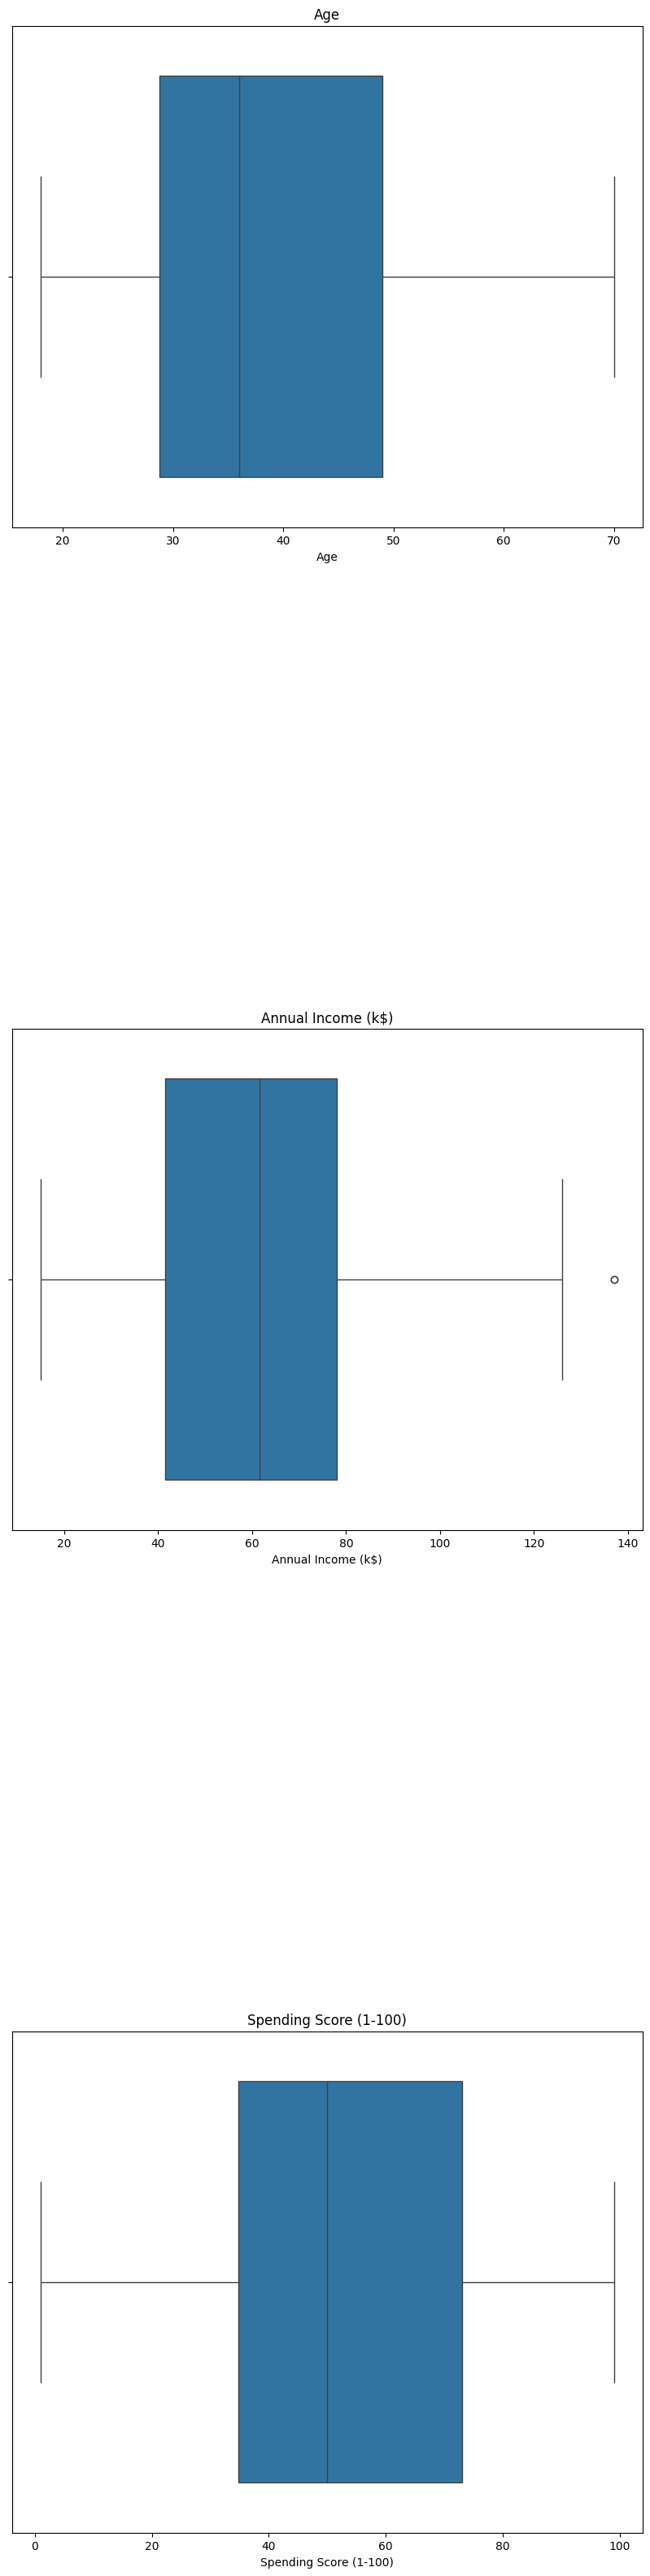

In [14]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 40))

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, x=col, ax=axes[i]) 
    axes[i].set_title(col)
    plt.subplots_adjust(hspace=1) 

## Scaling

In [15]:
num_columns = [col for col in df.columns if df[col].dtype != object]

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [17]:
#df[num_columns] = scaler.fit_transform(df[num_columns])

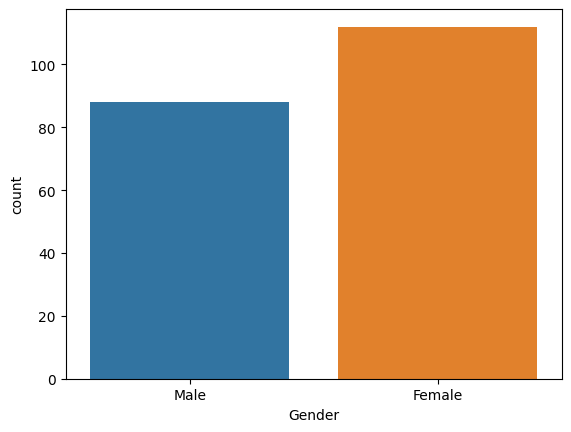

In [18]:
# gender analysis
sns.countplot(data =df , x='Gender',hue='Gender' )
plt.show()

In [19]:
# considering two features: annual income and spending score
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


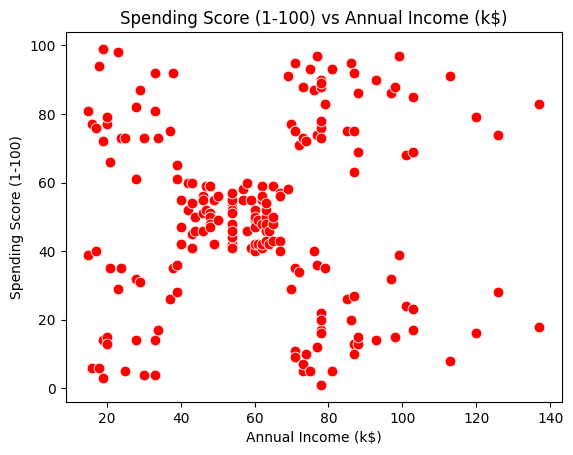

In [20]:
# scatterplot of the above data
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=X, s=60, color="red")
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Spending Score (1-100) vs Annual Income (k$)')

plt.show()

#  Model

In [21]:
from sklearn.cluster import KMeans

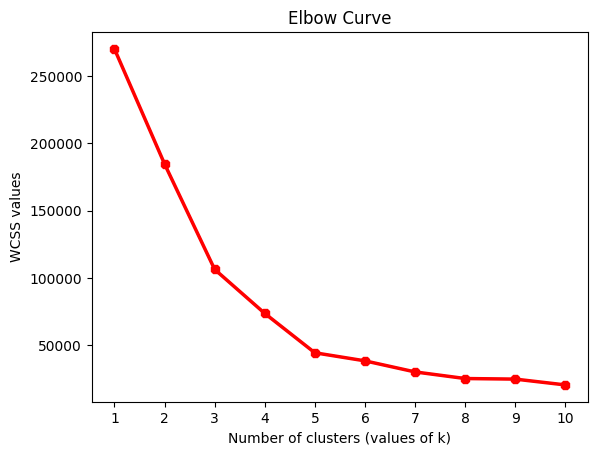

In [22]:
wcss = []
for i in range(1, 11):
    k_means = KMeans(n_clusters=i, n_init="auto")
    k_means.fit(X)
    wcss.append(k_means.inertia_)
    
# the elbow curve
plt.plot(range(1, 11), wcss)
plt.plot(range(1, 11), wcss, linewidth=2.5, color="red", marker="8")

plt.title("Elbow Curve")
plt.xlabel("Number of clusters (values of k)")
plt.ylabel("WCSS values")
plt.xticks(np.arange(1, 11, 1))

plt.show()


In [30]:
# taking k = 5
k_means_1 = KMeans(n_clusters=5)
k_means_1.fit(X)
y_pred = k_means_1.predict(X)
labels = k_means_1.labels_
df["label"] = y_pred
centroids = k_means_1.cluster_centers_
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),label
0,Male,19,15,39,0
1,Male,21,15,81,4
2,Female,20,16,6,0
3,Female,23,16,77,4
4,Female,31,17,40,0


In [31]:
centroids

array([[ 47.96      ,  43.25      ],
       [ 77.72413793,  81.06896552],
       [ 87.        ,  18.63157895],
       [108.18181818,  82.72727273],
       [ 25.72727273,  79.36363636]])

In [32]:
centroids = pd.DataFrame(data=centroids)

In [33]:
centroids

,0,1
0,47.960000,43.250000
1,77.724138,81.068966
2,87.000000,18.631579
3,108.181818,82.727273
4,25.727273,79.363636


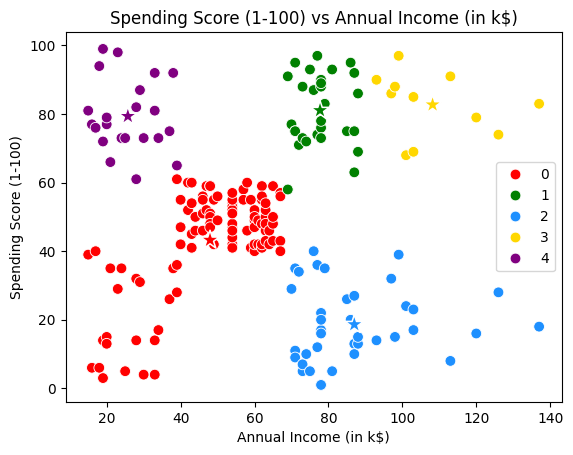

In [34]:
colors = ["red", "green", "dodgerblue", "gold", "purple",]

# scatterplot of the clusters
sns.scatterplot(
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="label", 
    palette=colors, 
    legend="full", 
    data=df, 
    s=60
)
sns.scatterplot(x=centroids.loc[:, 0], y=centroids.loc[:, 1], marker='*', s=200, color=colors)

plt.xlabel('Annual Income (in k$)')
plt.ylabel('Spending Score (1-100)') 
plt.title('Spending Score (1-100) vs Annual Income (in k$)')
plt.show()

## Silhouette Score

In [35]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(X, labels)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.4593850389758776
